In [1]:
#import warnings
#warnings.filterwarnings("ignore")

**Schritt 0.5 - Visualisierung des Grids**

(Ist glaube ich hilfreich es einmal am Anfang zu sehen) :^)

c:\Users\denni\anaconda3\envs\rl_project\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


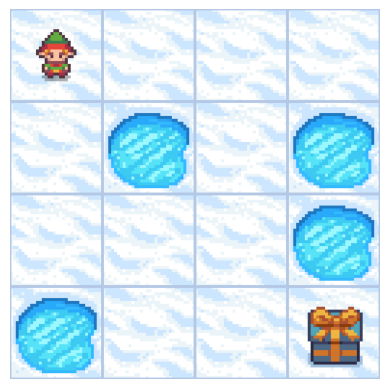

State grid (zur Veranschaulichung welcher Zustand sich wo befindet):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


In [2]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=True)

state, _ = env.reset(seed=42)

img = env.render()
plt.imshow(img)
plt.axis("off")
plt.show()

num_states = env.observation_space.n
grid_size = int(np.sqrt(num_states))
state_grid = np.arange(num_states).reshape((grid_size, grid_size))
print("State grid (zur Veranschaulichung welcher Zustand sich wo befindet):")
print(state_grid)

**Schritt 1**

Aufsetzen eines RL Environments, welches dabei helfen soll die einzelnen Schritte des Reinforcement Learnings zu verstehen, selber auszuprobieren und auch sich besser einzuprägen als nur Quellen durchzulesen, Tutorials durchzugehen und sonstiges.

In [3]:
import gymnasium as gym     # importiert die Gymnasium-Bibliothek die eine Sammlung von Umgebungen für Reinforcement Learning enthält z.b. frozenlake, cartpole, etc.
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False) # is slippery=False bedeutet, dass die Umgebung deterministisch ist, d.h. die Aktionen führen immer zum gleichen Ergebnis. Das erleichtert das Lernen, da es keine zufälligen Elemente gibt, die das Verhalten beeinflussen könnten oder das ein State mehrmals mal hintereinander kommt
# später wird noch is_slippery=True verwendet, damit die Umgebung stochastisch ist, d.h. die Aktionen können zu unterschiedlichen Ergebnissen führen, was das Lernen realistischer macht, aber auch schwieriger
state, _ = env.reset(seed=42)   # deterministische Umgebung, damit die Ergebnisse reproduzierbar sind

print("Start state:", state) 

Start state: 0


**Schritt 2 - Aktion ausführen**

In dem folgenden Abschnitt soll einer der Hauptbestanteile des RL eingesetzt werden - die Aktion.
Einfach erklärt funktioneiren Aktionen wie folgt:
Eine Aktion wird ausgeführt -> Welt reagiert -> man sieht ein Ergebnis

In [4]:
action = 2 # In der FrozenLake-Umgebung gelten folgenden Aktionen:  0: links, 1: unten, 2: rechts, 3: oben

action_names = {
    0: "links",
    1: "unten",
    2: "rechts",
    3: "oben"
}

next_state, reward, done, truncated, _ = env.step(action) # Aktion im Env ausführen
# next_state = neuer Zustand nach der Aktion
# reward = Belohnung/Bestrafung die der Agent für die Aktion erhält
# done = True wenn Ziel erreicht oder gefallen -> Episode ist beendet (Eine Episode ist die Sequenz von Zuständen, Aktionen, ... bis zum Ende einer Aufgabe z.B. könnte das Spiel einer Schachpartie eine ganze Episode sein mit dem Ergebnis: Sieg, Niederlage oder Unentschieden)
# truncated = True wenn die Episode aufgrund einer Zeitüberschrietung oder einer anderen Bedingung vorzeitig beendet wurde
# "_" = zusätzliche Informationen die von der Umgebung zurückgegeben werden können, aber hier nicht relevant sind

print("Next state:", next_state)    # Zeigt den Zustand nach der Aktion an   
print("Reward:", reward)            # Zeigt ob wir eine Belohnung oder Bestrafung erhalten haben
print("Done:", done)                # Zeigt ob die Episode beendet ist
print("Truncated:", truncated)      # Zeigt ob die Episode vorzeitig beendet wurde

Next state: 1
Reward: 0.0
Done: False
Truncated: False


**Schritt 3 - Der RL Loop**

Der Reinforcement Learning Loop ist der Kern. Er beschreibt folgendes RL_Prinzip:
beobachten -> handeln -> lernen -> wiederholen

In [5]:
state, _ = env.reset(seed=42)   # deterministische Umgebung, damit die Ergebnisse reproduzierbar sind und das Environment wieder bei "0" ist

done = False    # Variable um zu überprüfen ob die Episode beendet ist

while not done:

    action = env.action_space.sample() # zufällige Aktion aus dem Aktionsraum der Umgebung auswählen -> exploration keine "intelligente" Aktion sondern zufällige Aktion

    state, reward, done, truncated, _ = env.step(action) # Aktion im Env ausführen und bekommt Feedback

    print("State:", state)            # Zeigt den aktuellen Zustand an
    print("Reward:", reward)          # Zeigt die Belohnung oder Bestrafung
    print("Done:", done)              # Zeigt ob die Episode beendet ist
    print("Truncated:", truncated)    # Zeigt ob die Episode vorzeitig beendet wurde

State: 0
Reward: 0.0
Done: False
Truncated: False
State: 4
Reward: 0.0
Done: False
Truncated: False
State: 5
Reward: 0.0
Done: True
Truncated: False


**Schritt 3.5 - Position im Grid**

Aktuell sieht man immer nur eine Zahl z.B. State: 5, aber nicht wo genau man ist.
(Ausführlichere Variante von Schritt 3)

In [6]:
state, _ = env.reset(seed=42)   # deterministische Umgebung, damit die Ergebnisse reproduzierbar sind und das Environment wieder bei "0" ist

for step in range(20):                   # Schleife läuft, bis Episode normal oder vorzeitig endet

    action = env.action_space.sample()           # Wählt zufällige Aktion aus dem Aktionsraum

    print("Gewählte Aktion:", action, action_names[action])  # Gibt Zahl und Bedeutung der Aktion aus

    state, reward, done, truncated, _ = env.step(action)  # Führt Aktion aus und erhält Feedback vom Environment

    row = state // grid_size                    # Berechnet Zeile des neuen States
    col = state % grid_size                     # Berechnet Spalte des neuen States

    print("State:", state)                      # Gibt die neue State-Nummer aus
    print("Position:", (row, col))              # Gibt die Position im Grid aus
    print("Reward:", reward)                    # Gibt die Belohnung aus
    print("Done:", done)                        # Zeigt, ob Episode beendet ist
    print("Truncated:", truncated)              # Zeigt, ob Episode vorzeitig beendet wurde
    print("---")                                # Trennt die Schritte optisch -> sueht besser aus :)

    if done or truncated:                        # Überprüft, ob Episode normal oder vorzeitig beendet ist
        print("Episode beendet nach", step + 1, "Schritten.")
        break
    

Gewählte Aktion: 2 rechts
State: 1
Position: (0, 1)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 0 links
State: 0
Position: (0, 0)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 0 links
State: 0
Position: (0, 0)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 2 rechts
State: 1
Position: (0, 1)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 2 rechts
State: 2
Position: (0, 2)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 0 links
State: 1
Position: (0, 1)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 3 oben
State: 1
Position: (0, 1)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 0 links
State: 0
Position: (0, 0)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 3 oben
State: 0
Position: (0, 0)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 1 unten
State: 4
Position: (1, 0)
Reward: 0.0
Done: False
Truncated: False
---
Gewählte Aktion: 2 rechts
State: 5
Posi

**Schritt 4 - Transitions und Wahrscheinlichkeiten**

Bisher wurde im Notebook is_slippery = false für eine deterministische Umgebung benutzt. Es gibt aber auch die stochastischen Umgebungen, bei denen Aktionen zu unterschiedlichen Ergebnissen führen können.

Zum Beispiel: 
Wenn es auf dem FrozenLake rutschig ist, kann es passieren, dass ich auf State 2 lande anstelle auf Feld 5
> *Eine Aktion führt nicht immer zu genau einem Ergebnis SONDERN zu mehreren Ergebenissen mit Wahrscheinlichkeiten.*

Das ist ein weiteres Grundkonzept für weitere Themen, wie: Q-Values, Value Functions etc.

In [19]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=True) # Hier muss is_slippery=True sein, damit die Umgebung stochastisch ist, d.h. die Aktionen können zu unterschiedlichen Ergebnissen führen (siehe Output)
state = 6  
action = 0

transitions = env.unwrapped.P[state][action]  # Zugriff auf die Übergangswahrscheinlichkeiten für den gegebenen Zustand und Aktion

print(f"Transitions für State {state} und Action {action}:\n")

for prob, next_state, reward, done in transitions: # Jede mögliche Transition durchgehen
    print(f"Wahrscheinlichkeit", prob)  # Wie wahrscheinlich ist diese Transition
    print(f"Next State:", next_state)   # In welchen State kommen wir?
    print(f"Reward:", reward)           # Welche Belohnung erhalten wir? >> Aktuell keine (kommt später)
    print(f"Done:", done)               # Ist die Episode danach beendet?
    print("---")

Transitions für State 6 und Action 0:

Wahrscheinlichkeit 0.3333333333333333
Next State: 2
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 5
Reward: 0.0
Done: True
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 10
Reward: 0.0
Done: False
---


**Schritt 4.5 - Mehrere States als Mini-Experiment**

In [20]:
for state in range(4):
    for action in range(4):
        print(f"Transitions für State {state} und Action {action}:\n")
        transitions = env.unwrapped.P[state][action]  # Zugriff auf die Übergangswahrscheinlichkeiten für den gegebenen Zustand und Aktion
        for prob, next_state, reward, done in transitions: # Jede mögliche Transition durchgehen
            print(f"Wahrscheinlichkeit", prob)  # Wie wahrscheinlich ist diese Transition
            print(f"Next State:", next_state)   # In welchen State kommen wir?
            print(f"Reward:", reward)           # Welche Belohnung erhalten wir? >> Aktuell keine (kommt später)
            print(f"Done:", done)               # Ist die Episode danach beendet?
            print("---")
            

Transitions für State 0 und Action 0:

Wahrscheinlichkeit 0.3333333333333333
Next State: 0
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 0
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 4
Reward: 0.0
Done: False
---
Transitions für State 0 und Action 1:

Wahrscheinlichkeit 0.3333333333333333
Next State: 0
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 4
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 1
Reward: 0.0
Done: False
---
Transitions für State 0 und Action 2:

Wahrscheinlichkeit 0.3333333333333333
Next State: 4
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 1
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next State: 0
Reward: 0.0
Done: False
---
Transitions für State 0 und Action 3:

Wahrscheinlichkeit 0.3333333333333333
Next State: 1
Reward: 0.0
Done: False
---
Wahrscheinlichkeit 0.3333333333333333
Next S

Wichtiger Hinweis: Man kann nicht in alle vier Richtungen rutschen, sondern nur in drei Richtungen und zwar in die Richtung in die man die Action ausführt sowie in die beiden benachbarten Richtungen
> links: links, oben unten

> rechts: rechts, oben, unten

> oben: oben, links, rechts

> unten: unten, links, rechts

**Schritt 5 - Return / Discounted Return / gamma**

In [36]:
rewards = [0, 1, 1, 0, 1]                      # Beispielhafte Reward-Sequenz

gamma = 0.9                                    # Discount-Faktor

discounted_return = 0                          # Startwert für Return

for t, reward in enumerate(rewards):           # t = Zeitpunkt (0,1,2,...)
    
    discounted_return += (gamma ** t) * reward # Jeder Reward wird abgewertet
    
    print(f"Schritt {t}:")                     # Aktueller Zeitpunkt
    
    print(f"  Reward: {reward}")               # Aktueller Reward
    
    print(f"  Gewicht: {gamma**t:.4f}")        # Wie stark zählt dieser Reward
    
    print(f"  Aktueller Return: {discounted_return:.4f}")  # Gesamtwert bis jetzt
    
    print("-----")

gamma = 0.1 
discounted_return = 0 
print("Gamme = 0.1:")
for t, reward in enumerate(rewards):           
    discounted_return += (gamma ** t) * reward
    print(f"    {discounted_return:.4f}")

gamma = 0.99
discounted_return = 0 
print("Gamme = 0.99:")
for t, reward in enumerate(rewards):           
    discounted_return += (gamma ** t) * reward
    print(f"    {discounted_return:.4f}")

Schritt 0:
  Reward: 0
  Gewicht: 1.0000
  Aktueller Return: 0.0000
-----
Schritt 1:
  Reward: 1
  Gewicht: 0.9000
  Aktueller Return: 0.9000
-----
Schritt 2:
  Reward: 1
  Gewicht: 0.8100
  Aktueller Return: 1.7100
-----
Schritt 3:
  Reward: 0
  Gewicht: 0.7290
  Aktueller Return: 1.7100
-----
Schritt 4:
  Reward: 1
  Gewicht: 0.6561
  Aktueller Return: 2.3661
-----
Gamme = 0.1:
    0.0000
    0.1000
    0.1100
    0.1100
    0.1101
Gamme = 0.99:
    0.0000
    0.9900
    1.9701
    1.9701
    2.9307


**Schritt 6 - Policy definieren**

Eine Policy ist an sich eine einfach Regel:
> Wenn ich in State X bin, mache ich Aktion Y

Hier definieren wir erstmal eine feste Policy, damit wir danach Values und Q-Values berechnen können

Wichtig: Für die Stabilität wird erstmal eine deterministische Umgebung genutzt

In [59]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)

state, _ = env.reset(seed=42)

num_states = env.observation_space.n
num_actions = env.action_space.n

grid_size = int(np.sqrt(num_states))

print("Anzahl States:", num_states)
print("Anzahl Actions:", num_actions)
print("Grid Size:", grid_size, "x", grid_size)

print(action_names) # Nochmalige Ausgabe der vier Aktionsschritte zur Erinnerung (vergesse selber die Reihenfolge manchmal :D)

# Definieren der Policy für das FrozenLake-Environement
policy = {
    0: 1, 1:0, 2:0, 3:0, 4:1, 6:3, 8:2, 9:2, 10:1, 13:2, 14:2
}

# Terminal-States des Environements definieren
terminal_states = [5, 7, 11, 12, 15]
print ("Terminal States:", terminal_states)

# Definieren welche Aktionen in welchem Schritt durchgeführt werden (siehe policy)
print("POLICY:")
for state in range(num_states):
    if state in terminal_states:
        print(f"State {state}: Terminal State keine Action verfügbar")
    else:
        print(f"State {state}: Aktion {policy[state]} ({action_names[policy[state]]})")

Anzahl States: 16
Anzahl Actions: 4
Grid Size: 4 x 4
{0: 'links', 1: 'unten', 2: 'rechts', 3: 'oben'}
Terminal States: [5, 7, 11, 12, 15]
POLICY:
State 0: Aktion 1 (unten)
State 1: Aktion 0 (links)
State 2: Aktion 0 (links)
State 3: Aktion 0 (links)
State 4: Aktion 1 (unten)
State 5: Terminal State keine Action verfügbar
State 6: Aktion 3 (oben)
State 7: Terminal State keine Action verfügbar
State 8: Aktion 2 (rechts)
State 9: Aktion 2 (rechts)
State 10: Aktion 1 (unten)
State 11: Terminal State keine Action verfügbar
State 12: Terminal State keine Action verfügbar
State 13: Aktion 2 (rechts)
State 14: Aktion 2 (rechts)
State 15: Terminal State keine Action verfügbar


**Schritt 7 - State-Value Function V(s)**

V(s) bedeutuet hier:
> Wie gut ist dieser Zustand, wenn ich ab jetzt der Policy folge?

Also an sich startet man in einem State, macht immer das was die Policy sagt und summiert die zukünftigen Rewards

Bnutzen der Bellman-Idee:
> Wert des aktuellen Zustands = sofortige Reward + Wert des nächsten Zustands

als Formel:

> V(s) = reward + gamma * V(next_state)

In [60]:
gamma = 0.9
print("Gamma:", gamma)

# Funktion zur Berechnung der State-Value-Funktion V(s) für einen gegebenen Zustand s unter der definierten Policy
def compute_state_value(state):
    if state in terminal_states:
        return 0
    
    action = policy[state]
    transition = env.unwrapped.P[state][action][0]

    prob, next_state, reward, done = transition

    return reward + gamma * compute_state_value(next_state)

V = {}

for state in range(num_states):
    V[state] = compute_state_value(state)

print("State Value V(s):")
for state in range(num_states):
    if state in terminal_states:
        print(f"Terminal State ({state}) -> Terminal State V = 0")
    else:
        print(f"State {state}: V = {V[state]:.4f}")

value_grid = np.zeros((grid_size, grid_size))
for state in range(num_states):
    row = state // grid_size
    col = state % grid_size
    value_grid[row, col] = V[state]

print("State-Value-Grid:")
print(value_grid)

Gamma: 0.9
State Value V(s):
State 0: V = 0.5905
State 1: V = 0.5314
State 2: V = 0.4783
State 3: V = 0.4305
State 4: V = 0.6561
Terminal State (5) -> Terminal State V = 0
State 6: V = 0.4305
Terminal State (7) -> Terminal State V = 0
State 8: V = 0.7290
State 9: V = 0.8100
State 10: V = 0.9000
Terminal State (11) -> Terminal State V = 0
Terminal State (12) -> Terminal State V = 0
State 13: V = 0.9000
State 14: V = 1.0000
Terminal State (15) -> Terminal State V = 0
State-Value-Grid:
[[0.59049    0.531441   0.4782969  0.43046721]
 [0.6561     0.         0.43046721 0.        ]
 [0.729      0.81       0.9        0.        ]
 [0.         0.9        1.         0.        ]]


**Schritt 8 - Action-Value Function Q(s, a)**

Die Q-Value Q(s, a) sagt im Gegensatz zur State Value V(s):
> Wie gut ist es, wenn ich in einem bestimmten Zustand eine bestimmte Aktion ausführe und danach der Policy folge?

Also:
- V(s) = Bewertung des Zustands
- Q(s, a) = Bewertung der Aktion in diesem Zustand

Es gilt die folgende Formel:
> Q(s, a) = reward + gamma * V(next_state)

In [64]:
def compute_q_value(state, action):
    if state in terminal_states:
        return 0
    
    transition = env.unwrapped.P[state][action][0]

    prob, next_state, reward, done = transition

    return reward + gamma * V[next_state]

Q = {}

for state in range(num_states):
    for action in range(num_actions):
        Q[(state, action)] = compute_q_value(state, action)

print("Q-Values Q(s,a):")
for state in range(num_states):
    print(f"\nState {state}:")
    if state in terminal_states:
        print("  Terminal State keine Aktionen verfügbar")
        continue
    for action in range(num_actions):
        print(
            f"    Aktion {action} ({action_names[action]}): "
            f"Q = {Q[(state, action)]:.4f}"
        )

Q-Values Q(s,a):

State 0:
    Aktion 0 (links): Q = 0.5314
    Aktion 1 (unten): Q = 0.5905
    Aktion 2 (rechts): Q = 0.4783
    Aktion 3 (oben): Q = 0.5314

State 1:
    Aktion 0 (links): Q = 0.5314
    Aktion 1 (unten): Q = 0.0000
    Aktion 2 (rechts): Q = 0.4305
    Aktion 3 (oben): Q = 0.4783

State 2:
    Aktion 0 (links): Q = 0.4783
    Aktion 1 (unten): Q = 0.3874
    Aktion 2 (rechts): Q = 0.3874
    Aktion 3 (oben): Q = 0.4305

State 3:
    Aktion 0 (links): Q = 0.4305
    Aktion 1 (unten): Q = 0.0000
    Aktion 2 (rechts): Q = 0.3874
    Aktion 3 (oben): Q = 0.3874

State 4:
    Aktion 0 (links): Q = 0.5905
    Aktion 1 (unten): Q = 0.6561
    Aktion 2 (rechts): Q = 0.0000
    Aktion 3 (oben): Q = 0.5314

State 5:
  Terminal State keine Aktionen verfügbar

State 6:
    Aktion 0 (links): Q = 0.0000
    Aktion 1 (unten): Q = 0.8100
    Aktion 2 (rechts): Q = 0.0000
    Aktion 3 (oben): Q = 0.4305

State 7:
  Terminal State keine Aktionen verfügbar

State 8:
    Aktion 0 (lin

**Schritt 9 - Policy verbessern**

Jetzt nutzen wir aus den Q-Werten etwas Nützliches:
Für jeden State schauen wir:
> Welche Aktion hat den höchsten Q-Wert?

Dann bauen wir daraus eine verbesserte Policy

Zum Beispiel hat ein State s die folgenden Q-Werte:
- Q(s, left) = 0.5
- Q(s, right) = 0.2
- Q(s, up) = 0.1
- Q(s, down) = 0.3

-> Nimm Aktion nach links (da höchster Q-Wert)

In [65]:
improved_policy = {}    # leeres Dictionary für verbesserte Policy

for state in range(num_states): 

    if state in terminal_states:    # prüft ob State terminal
        improved_policy[state] = None # keine Aktion für terminalen State
        continue    

    best_action = max(      # sucht die Aktion mit dem höchsten Q-Wert für diesen State
        range(num_actions),  # alle Möglichen Aktionen durchgehen
        key=lambda action: Q[(state, action)] # Bewertet jede Aktion anhand ihres Q-Werts
    )
    improved_policy[state] = best_action # speichert beste Aktion in neuer Policy

print("Verbesserte Policy:")

for state in range(num_states):
    if  improved_policy[state] is None:
        print(f"State {state}: terminal")
    else:
        print(
            f"State {state}: Aktion {improved_policy[state]}"
            f"({action_names[improved_policy[state]]})"
        )


print("Vergleich: alte Policy vs. verbesserte Policy")

for state in range(num_states):
    if state in terminal_states:
        print(f"State {state}: terminal")
    else:
        old_action = policy[state]
        new_action = improved_policy[state]
        
        print(
            f"State {state}:"
            f" alt = {old_action} ({action_names[old_action]});"
            f" neu = neue Aktion {new_action} ({action_names[new_action]})"
        )

Verbesserte Policy:
State 0: Aktion 1(unten)
State 1: Aktion 0(links)
State 2: Aktion 0(links)
State 3: Aktion 0(links)
State 4: Aktion 1(unten)
State 5: terminal
State 6: Aktion 1(unten)
State 7: terminal
State 8: Aktion 2(rechts)
State 9: Aktion 1(unten)
State 10: Aktion 1(unten)
State 11: terminal
State 12: terminal
State 13: Aktion 2(rechts)
State 14: Aktion 2(rechts)
State 15: terminal
Vergleich: alte Policy vs. verbesserte Policy
State 0: alt = 1 (unten); neu = neue Aktion 1 (unten)
State 1: alt = 0 (links); neu = neue Aktion 0 (links)
State 2: alt = 0 (links); neu = neue Aktion 0 (links)
State 3: alt = 0 (links); neu = neue Aktion 0 (links)
State 4: alt = 1 (unten); neu = neue Aktion 1 (unten)
State 5: terminal
State 6: alt = 3 (oben); neu = neue Aktion 1 (unten)
State 7: terminal
State 8: alt = 2 (rechts); neu = neue Aktion 2 (rechts)
State 9: alt = 2 (rechts); neu = neue Aktion 1 (unten)
State 10: alt = 1 (unten); neu = neue Aktion 1 (unten)
State 11: terminal
State 12: termin

**Wichtig: Diese Policy ist nicht optimal, da die Logik wie folgt ist:**

> Es wird bei der Berechnung der Q-Werte nur betrachtet, was passiert, wenn eine Aktion ausgeführt wird und anschließend weiterhin der aktuellen (alten) Policy gefolgt wird. Dadurch basieren die Q-Werte auf der Bewertung dieser bestehenden Policy und nicht auf der global optimalen Strategie.

> Die gewählte Aktion mit dem höchsten Q-Wert ist daher die beste Aktion relativ zur aktuellen Policy (greedy bezüglich Qπ), aber nicht zwangsläufig die global optimale Aktion.

> Durch die Policy-Verbesserung wird die Policy jedoch nicht schlechter, sondern entweder besser oder bleibt unverändert. Um die optimale Policy zu erreichen, muss dieser Prozess iterativ wiederholt werden (Policy Iteration), was in den nächsten Schritten betrachtet wird :D